# RiMEA 12b: Length of a Bottleneck

This notebook demonstrates the current public implementation of RiMEA Test 12b. We load one base bottleneck scenario, clone it into a short and a long bottleneck variant, run both variants across multiple seeds, and compare the evacuation times.

The expected qualitative result is simple: for the same bottleneck width, the **longer bottleneck should evacuate more slowly**.


In [50]:
from datetime import datetime
print(f"Executed on {datetime.now().astimezone().strftime('%d %B %Y, %H:%M %Z')}")

Executed on 12 July 2026, 16:57 CEST


In [51]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pedpy

from jupedsim_scenarios import load_scenario, run_scenario


In [52]:
plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "#f7f7f5",
        "axes.edgecolor": "#3a3a3a",
        "axes.labelcolor": "#1d1d1d",
        "axes.titleweight": "bold",
        "font.size": 11,
        "axes.titlesize": 15,
        "axes.labelsize": 13,
    }
)

VARIANT_COLORS = {
    0.2: "#2563EB",
    5.0: "#D97706",
}
MEASUREMENT_LINE = pedpy.MeasurementLine([(10.0, 3), (10.0, 7)])


## Load the Base Scenario

The scenario directory contains the short bottleneck geometry from the current public test implementation. The notebook deep-copies the raw data before creating the long bottleneck variant, so each run stays isolated.


In [53]:
SCENARIO_DIR = Path("scenario_files") / "Rimea-12a-goal-position.zip"
base_scenario = load_scenario(str(SCENARIO_DIR))
print(base_scenario.summary())

Scenario: /Users/elif/Desktop/HiWi/jupedsim-web-community/standards/rimea/scenario_files/Rimea-12a-goal-position.zip
  Model:         CollisionFreeSpeedModel
  Seed:          42
  Max time:      300s
  Exits:         1
  Distributions: 1
  Stages:        0
  Zones:         0
  Journeys:      0
  Agents:        ~150
    jps-distributions_0: 150 agents


In [54]:
SCENARIO_DIR2 = Path("scenario_files") / "Rimea-12b-bottleneck-length.zip"
long_scenario = load_scenario(str(SCENARIO_DIR2))
print(long_scenario.summary())

Scenario: /Users/elif/Desktop/HiWi/jupedsim-web-community/standards/rimea/scenario_files/Rimea-12b-bottleneck-length.zip
  Model:         CollisionFreeSpeedModel
  Seed:          42
  Max time:      300s
  Exits:         1
  Distributions: 1
  Stages:        0
  Zones:         0
  Journeys:      0
  Agents:        ~150
    jps-distributions_0: 150 agents


## Run the Bottleneck-Length Scenarios


In [56]:
%%capture
result_base = run_scenario(base_scenario,seed=42)
traj_base = pedpy.TrajectoryData(
    result_base.trajectory_dataframe()[["id", "frame", "x", "y"]].copy(),
    frame_rate=result_base.frame_rate,
)
walkable_area_base = pedpy.WalkableArea(base_scenario.walkable_polygon)


result_long = run_scenario(long_scenario,seed=42)
traj_long = pedpy.TrajectoryData(
    result_long.trajectory_dataframe()[["id", "frame", "x", "y"]].copy(),
    frame_rate=result_long.frame_rate,
)
walkable_area_long = pedpy.WalkableArea(long_scenario.walkable_polygon)

## Plot Geometry and Trajectories

Each panel shows the room geometry, the bottleneck entrance line, and the trajectories of agents. The long bottleneck should visibly keep agents constrained for longer before they spread into room 2.


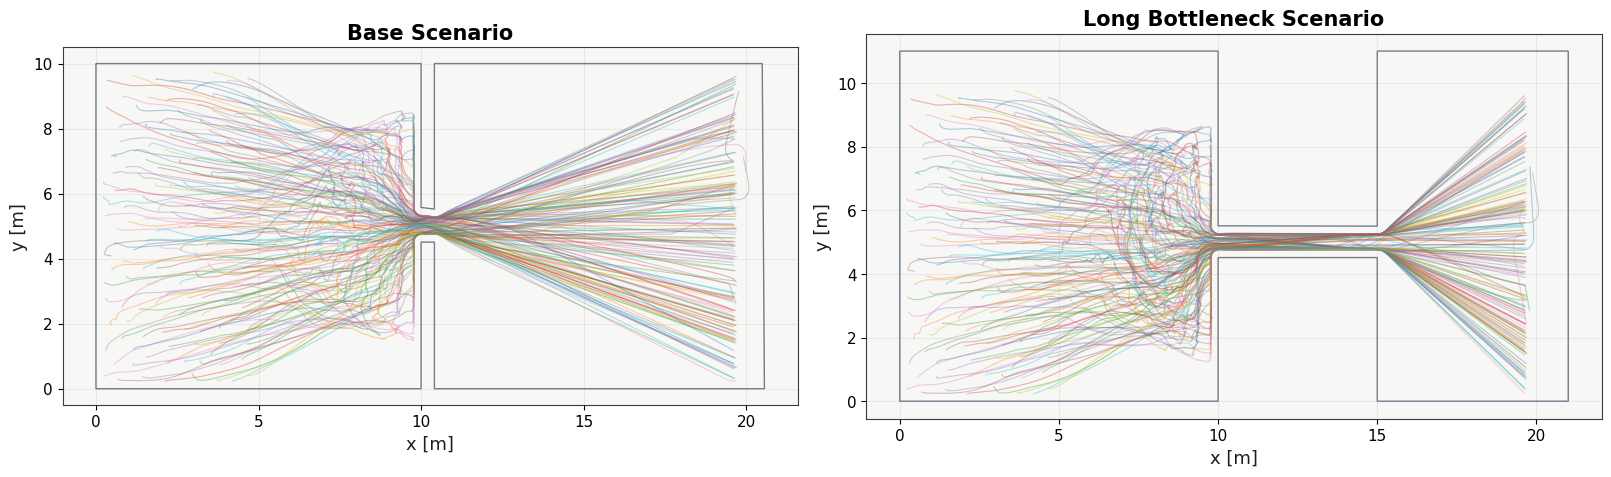

In [57]:
def plot_geometry_and_trajectories(
    trajectory,
    walkable_area,
    title,
    ax,
    *,
    trajectory_alpha=0.35,
    trajectory_linewidth=0.8,
):
    """Plot the walkable geometry and each pedestrian trajectory."""

    # Plot the walkable-area boundary.
    pedpy.plot_walkable_area(
        walkable_area=walkable_area,
        axes=ax,
    )

    data = trajectory.data

    # Plot one line per pedestrian.
    for _, pedestrian_data in data.groupby("id"):
        pedestrian_data = pedestrian_data.sort_values("frame")

        ax.plot(
            pedestrian_data["x"],
            pedestrian_data["y"],
            linewidth=trajectory_linewidth,
            alpha=trajectory_alpha,
        )

    ax.set_title(title)
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(alpha=0.2)


fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(16, 6),
    constrained_layout=True,
)

plot_geometry_and_trajectories(
    trajectory=traj_base,
    walkable_area=walkable_area_base,
    title="Base Scenario",
    ax=axes[0],
)

plot_geometry_and_trajectories(
    trajectory=traj_long,
    walkable_area=walkable_area_long,
    title="Long Bottleneck Scenario",
    ax=axes[1],
)

plt.show()

## Accaptance - Compare Evacuation Times

The long bottleneck scenario should have a higher evacuation time for room 1.


In [58]:
nt_base, crossing_base = pedpy.compute_n_t(traj_data=traj_base, measurement_line=MEASUREMENT_LINE)
nt_long, crossing_long = pedpy.compute_n_t(traj_data=traj_long, measurement_line=MEASUREMENT_LINE)
summary = {
    "Short Bottleneck Room 1 Evacuation Time": round(float(crossing_base['frame'].max() / traj_base.frame_rate), 2),
    "Long Bottleneck Room 1 Evacuation Time": round(float(crossing_long['frame'].max() / traj_long.frame_rate), 2),
    "Number of Evacuated- Short Bottleneck ": int(len(crossing_base)),
    "Number of Evacuated- Long Bottleneck": int(len(crossing_long)),
}
summary

{'Short Bottleneck Room 1 Evacuation Time': 126.9,
 'Long Bottleneck Room 1 Evacuation Time': 172.3,
 'Number of Evacuated- Short Bottleneck ': 150,
 'Number of Evacuated- Long Bottleneck': 150}